In [1]:
import os
import sys
from pathlib import Path
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_NUM_INTRAOP_THREADS"] = "2"
os.environ["TF_NUM_INTEROP_THREADS"] = "2"
os.environ["OMP_NUM_THREADS"] = "2"
project_directory = Path.cwd()
if not (project_directory / "common.py").is_file():
    project_directory = project_directory.parent
sys.path.insert(0, str(project_directory))
from common import ROOT, MODE, SEED, BATCH, EPOCHS, CLASSES, ensure_data, split_paths, seed_all, load_array, evaluate_binary, save_metrics
seed_all()
print(f"Project: {ROOT.name} | mode: {MODE} | seed: {SEED}")


Project: land-classification-github | mode: quick | seed: 7331


In [2]:
from pathlib import Path
from PIL import Image
from common import paths_and_labels, DATA
paths, labels = paths_and_labels()
print("Class counts:", {name: int((labels == i).sum()) for i, name in enumerate(CLASSES)})
print("First path:", paths[0].relative_to(ROOT))
with Image.open(paths[0]) as image:
    print("Image size and mode:", image.size, image.mode)


Class counts: {'class_0_non_agri': 240, 'class_1_agri': 240}
First path: data/images_dataSAT/class_0_non_agri/tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6497.jpg
Image size and mode: (64, 64) RGB


In [3]:
import time
import tracemalloc
import numpy as np
sample_paths = np.concatenate((paths[:60], paths[-60:]))
tracemalloc.start()
started = time.perf_counter()
in_memory = load_array(sample_paths)
memory_time = time.perf_counter() - started
_, memory_peak = tracemalloc.get_traced_memory()
tracemalloc.stop()
def image_generator(items):
    for path in items:
        with Image.open(path) as image:
            yield np.asarray(image.convert("RGB").resize((64, 64)), dtype=np.float32) / 255.0
tracemalloc.start()
started = time.perf_counter()
consumed = sum(float(image.mean()) for image in image_generator(sample_paths))
generator_time = time.perf_counter() - started
_, generator_peak = tracemalloc.get_traced_memory()
tracemalloc.stop()
print(f"In memory: {in_memory.shape}; peak {memory_peak / 2**20:.2f} MiB; {memory_time:.2f} s")
print(f"Generator: {len(sample_paths)} images; peak {generator_peak / 2**20:.2f} MiB; {generator_time:.2f} s; mean checksum {consumed:.2f}")


In memory: (120, 64, 64, 3); peak 11.30 MiB; 0.11 s
Generator: 120 images; peak 0.15 MiB; 0.10 s; mean checksum 35.47


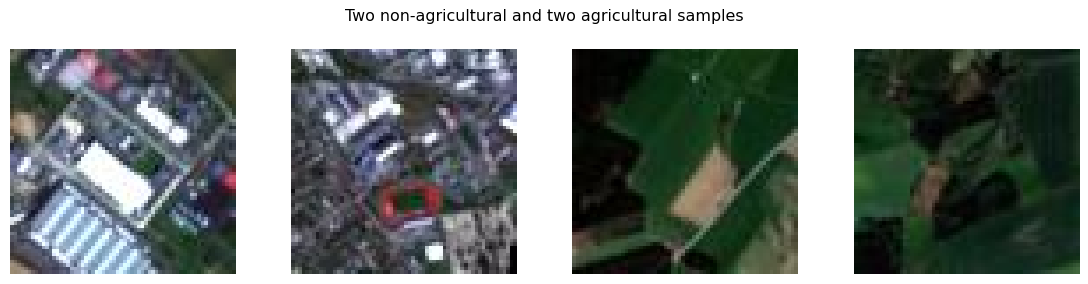

In [4]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for axis, image in zip(axes, in_memory[[0, 1, 60, 61]]):
    axis.imshow(image)
    axis.axis("off")
fig.suptitle("Two non-agricultural and two agricultural samples")
plt.tight_layout()
plt.show()
